<a href="https://colab.research.google.com/github/NahomKidane/ai301-labs/blob/main/m03-embeddings/guided-labs/AI301_Guided_Lab_Part2_Concept_How_word2vec_Learns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Guided Lab, Part 2: How word2vec Learns

**AI 301: Natural Language Processing and Conversational AI**

**Module 3 · Embeddings**

> Save a copy before you start. File, then Save a copy in Drive, and work in your copy.
>
> Leave the runtime on CPU. word2vec training here runs on the CPU and a GPU does not speed it up.
>
> Nothing is downloaded. Everything trains on eight sentences written into the notebook.
>
> Section 3 installs gensim, which Colab does not ship.

Follow the course AI use policy. This is a self-study lab. Nothing is submitted and nothing is graded.

**Name:**

---

One question runs through this lab:

> ## Where does a word vector get its meaning from?

Part 1 gave you a vector for every token id, but those vectors arrived already trained inside a model
you downloaded, with no way to see what produced them. This part trains a separate model of its own,
word2vec, on eight sentences you can read, so you can watch where the numbers come from. Part 3 then
scales it up and finds where the method breaks.

```
a corpus of sentences
        |
   slide a window over it
        |
  (context words, centre word) pairs
        |
   train a small network to predict one from the other
        |
   throw the network away, keep the weight matrix
        |
        v
   one vector per word
```

**Check Your Understanding** boxes appear throughout. Answer first, then click to reveal. They are
not graded.

# 1. The distributional hypothesis

word2vec rests on one claim about language, stated by Zellig Harris in 1956 and put most memorably
by J. R. Firth the year after:

> You shall know a word by the company it keeps.
> J. R. Firth, A Synopsis of Linguistic Theory, 1957

Words that appear in similar contexts tend to mean similar things. Nothing about the world, nothing
about definitions, only which words show up near which other words.

Read these two sentences with a word blanked out:

```
The ____ barked at the mail carrier.
The ____ chased a squirrel up the tree.
```

You did not need a dictionary. The surrounding words narrowed it to a small set, and `dog` is in that
set because `dog` is the word that usually appears in those slots.

word2vec turns that observation into a training signal. Slide a window over a corpus, take each
position as a training example, and ask a small network to predict one part of the window from the
other. The network never sees a definition. It only ever sees co occurrence.

> **Check Your Understanding**
>
> The word `bank` appears near `river` in some sentences and near `loan` in others. What does a single word2vec vector for `bank` end up representing?

<details>
<summary>Show answer</summary>

One vector averaged over both senses. word2vec assigns exactly one vector per word type, so the two senses blend into a single point that sits between them and matches neither well. A contextual model does not have this problem, which is what Part 1 measured on `bank`. That is a different model with its own vectors, not a repair applied to this one.

</details>

# 2. Two ways to set up the prediction

There are two training objectives, and they are mirror images.

**CBOW**, continuous bag of words, predicts the centre word from the surrounding context.

```
the  quick  ____  fox  jumps     ->     brown
```

**Skip-gram** predicts the surrounding context from the centre word.

```
brown     ->     the, quick, fox, jumps
```

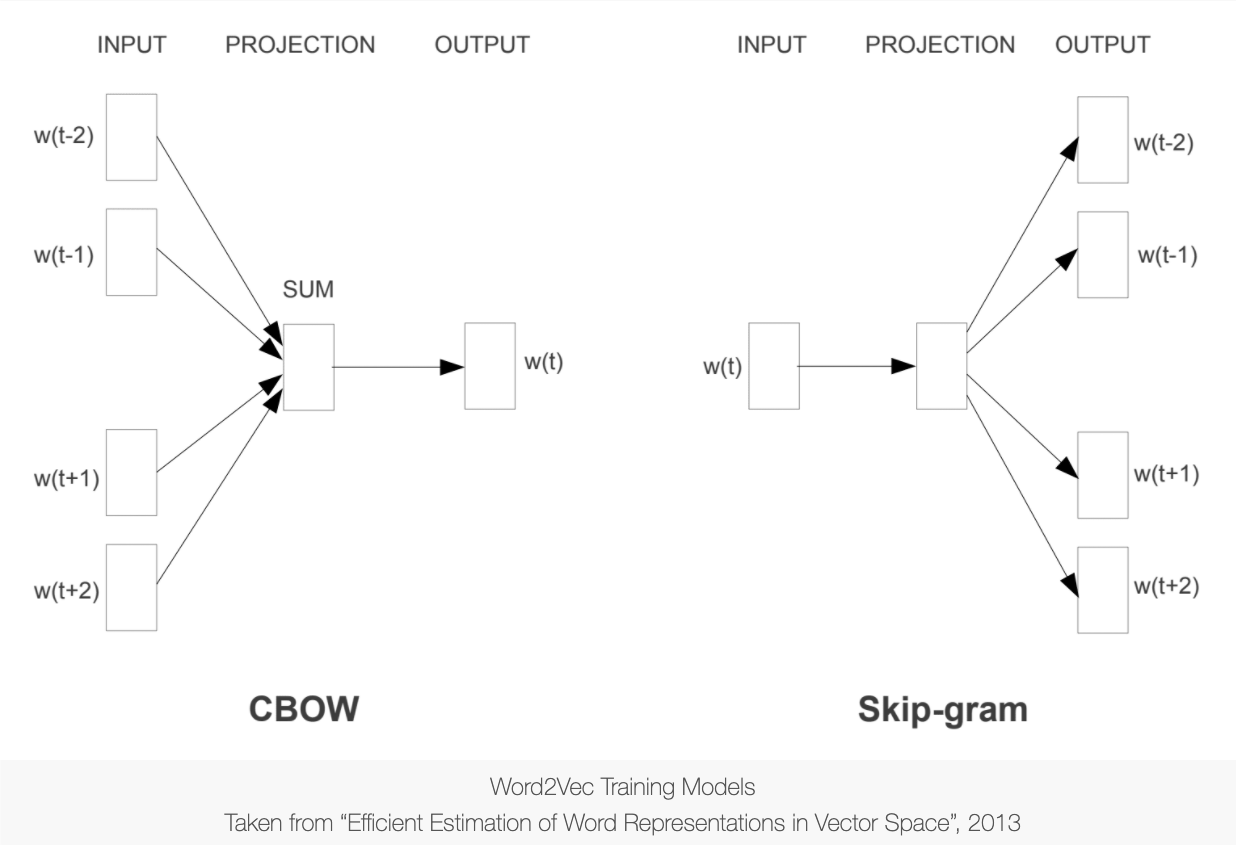

Word2Vec training models, from Mikolov et al., Efficient Estimation of Word Representations in Vector Space, 2013. `w(t)` is the centre word and `w(t-2)` through `w(t+2)` are its context. The arrows are the only difference between the two.

| | CBOW | Skip-gram |
|---|---|---|
| Input | context words | centre word |
| Output | centre word | context words |
| Training examples per position | one | one per context word |
| Speed | faster | slower |
| Rare words | smoothed over by the context | learned better, each occurrence produces several examples |

Skip-gram produces more training examples from the same corpus, which is why it usually wins on small
data and on rare words. This lab uses skip-gram, `sg=1` in gensim.

## 2.1 · CBOW, step by step

The corpus becomes token id sequences, then a window slides over them to make one training example
per position. Each example is a block of context ids, `X`, paired with the centre word id, `Y`.

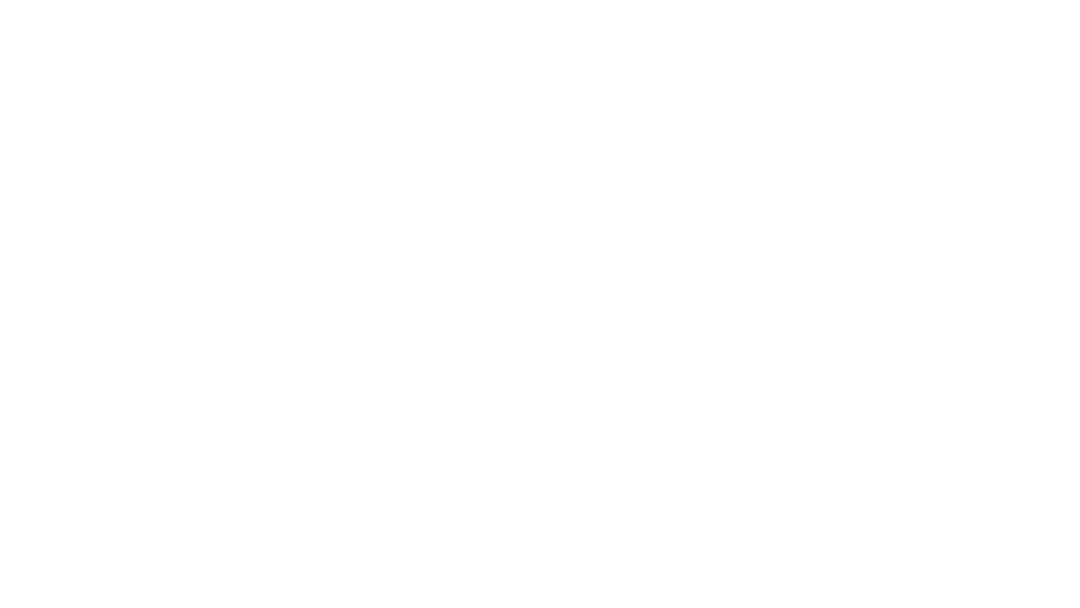

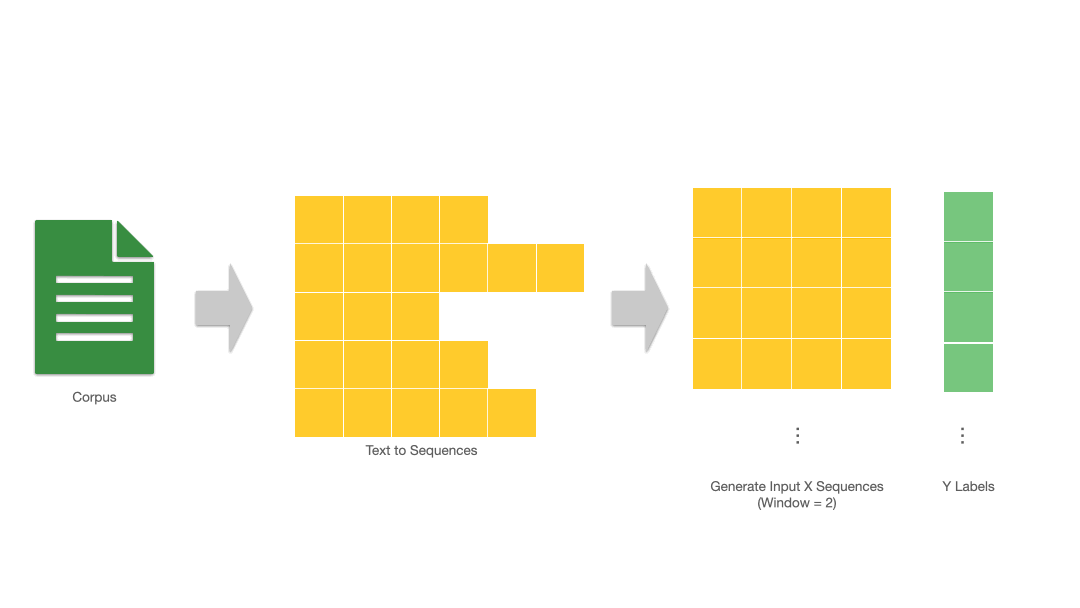

The same steps as one picture, for reading without the animation.

The network is three layers. An embedding layer turns each context id into a vector, an average
pooling layer collapses those vectors into one by averaging them dimension by dimension, and a softmax
turns that into a probability over the whole vocabulary. The loss compares that distribution against
the one hot vector for the true centre word.

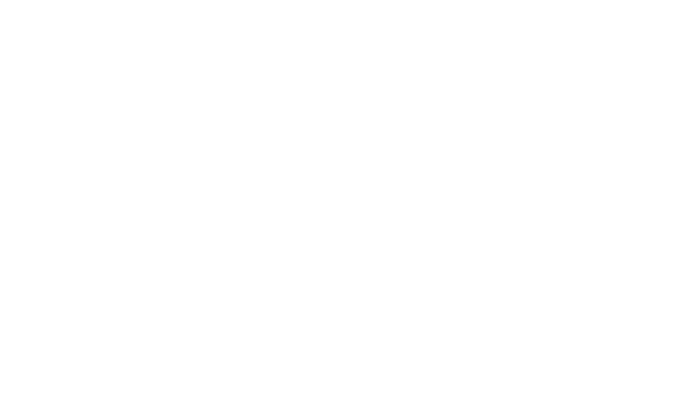

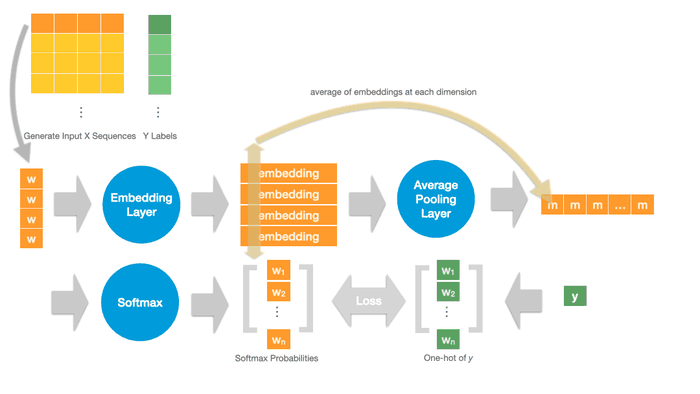

The same network as one picture.

The embedding layer is the part that is kept. Everything downstream of it exists only to produce a
gradient, and it is discarded once training ends.

## 2.2 · Skip-gram, step by step

Skip-gram flips the direction, and gensim trains it with **negative sampling** rather than a softmax
over the whole vocabulary. Each training example is a pair of words with a yes or no label: was this
context word actually near this target word, or was it drawn at random. A sigmoid produces one
probability and the loss compares it against that 0 or 1.

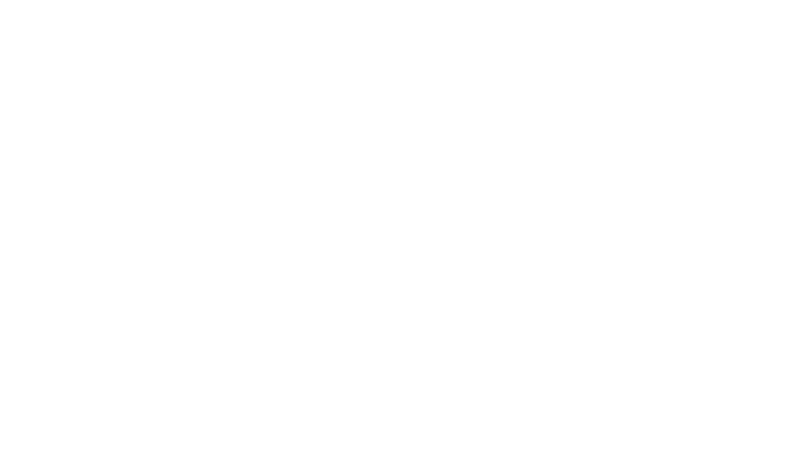

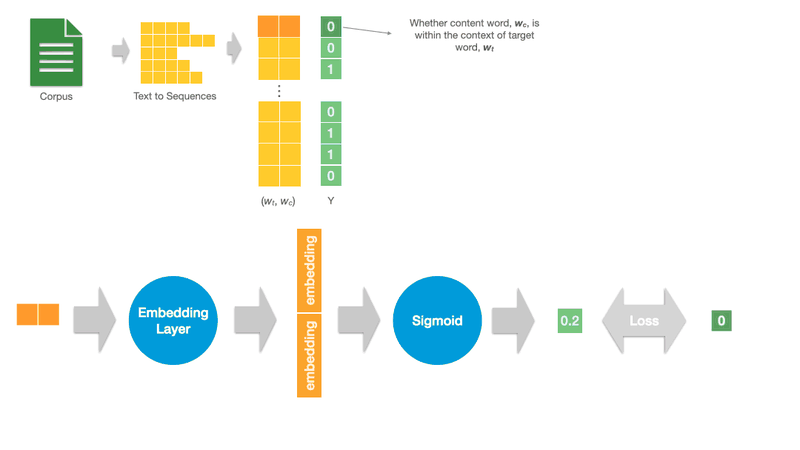

The same pass as one picture.

This is what `negative=5` means in the code below. For every real pair, five fake pairs are drawn from
the vocabulary as negative examples. Turning one prediction over twenty thousand words into a handful
of yes or no questions is what makes word2vec fast enough to train on billions of tokens.

> **Check Your Understanding**
>
> With a window of 2, how many training examples does skip-gram produce from one centre word position in the middle of a sentence, and how many does CBOW produce?

<details>
<summary>Show answer</summary>

Skip-gram produces four, one for each of the two words to the left and the two to the right. CBOW produces one, with all four context words averaged into a single input. Same window, four times the examples.

</details>

gensim is not part of the Colab image, so install it before anything else. If the import in the next
cell fails, choose Runtime, then Restart session, and run this cell again.

In [ ]:
!pip install -q gensim

# 3. A corpus you can read

Eight sentences, written for this lab. Three of them are about weather, three about the fox and the
dog, two about breakfast food. The `labels` list below records which is which, and it is used later
only to colour the plots. The model never sees it. Nothing about these topics reaches training.

In [ ]:
corpus = [
    "The sky is blue and beautiful.",
    "Love this blue and beautiful sky!",
    "The quick brown fox jumps over the lazy dog.",
    "A king's breakfast has sausages, ham, bacon, eggs, toast and beans",
    "I love green eggs, ham, sausages and bacon!",
    "The brown fox is quick and the blue dog is lazy!",
    "The sky is very blue and the sky is very beautiful today",
    "The dog is lazy but the brown fox is quick!",
]

labels = ["weather", "weather", "animals", "food",
          "food", "animals", "weather", "animals"]

print(len(corpus), "documents")

gensim wants a list of token lists, not a list of strings. Strip punctuation, lowercase, split on
whitespace.

In [ ]:
import re

tokenised = []
for doc in corpus:
    # remove everything that is not a letter or a space
    cleaned = re.sub(r"[^a-zA-Z\s]", "", doc)
    # lowercase so The and the count as the same word
    cleaned = cleaned.lower().strip()
    # split on whitespace into a list of tokens
    tokenised.append(cleaned.split())

print(tokenised[0])
print(tokenised[3])

### What this shows

This is whitespace tokenization, not the subword tokenization from Module 2. `king's` became `kings`
because the apostrophe was stripped. word2vec has no subword mechanism, so a word it has never seen
has no vector at all. A Module 2 tokenizer never has that problem, because it can always fall back to
pieces.

# 4. Training word2vec

Two trainings on the same eight sentences. The only difference is how many passes the model makes
over the data.

In [ ]:
from gensim.models import Word2Vec

toy100 = Word2Vec(
    tokenised,        # the corpus, a list of token lists
    vector_size=10,   # how many numbers in each word vector
    window=5,         # how far to look on each side of the centre word
    min_count=1,      # keep every word, even ones seen once
    sg=1,             # 1 is skip-gram, 0 is CBOW
    seed=123,         # fix the random start so runs match
    workers=1,        # one thread, needed for the seed to reproduce exactly
    negative=5,       # negative sampling, 5 wrong words per correct one
    epochs=100,       # passes over the corpus
)

print("vocabulary size:", len(toy100.wv.index_to_key))
print(toy100.wv.index_to_key)

### What this shows

Thirty words in the whole vocabulary. `index_to_key` is ordered by frequency, so `the` comes first.
Every one of these words now has a ten number vector, and that is the entire model.

Note `workers=1`. gensim splits training across threads by default, and the order in which threads
finish changes the result, so a seed only reproduces exactly on a single thread.

In [ ]:
import numpy as np

print(np.round(toy100.wv["sky"], 3))

### What this shows

Ten numbers. No dimension means anything on its own. There is no weather axis. The only thing that
carries meaning is where this point sits relative to the other twenty nine.

Whether it carries anything at all is the next question.

## 4.1 · Does it work?

Two vectors are compared with **cosine similarity**, which measures the angle between them and
ignores their length. Two vectors pointing the same way score 1.0, two at right angles score 0.0, two
pointing opposite ways score -1.0. In practice on word vectors the scores sit between about 0.0 and
1.0, so read them as a ranking rather than as a percentage: what matters is that within topic pairs
score higher than across topic pairs.

Length is ignored on purpose. A frequent word gets a longer vector simply because it was updated more
often during training, and that has nothing to do with meaning.

Three of the pairs below sit inside one topic and two cross topics. If the model learned anything,
the first three score higher than the last two.

In [ ]:
import pandas as pd

PAIRS = [
    ("sky", "beautiful"),
    ("fox", "dog"),
    ("ham", "bacon"),
    ("sky", "dog"),
    ("ham", "sky"),
]

def similarity_table(model, pairs):
    rows = []
    for a, b in pairs:
        score = model.wv.similarity(a, b)
        rows.append({"word 1": a, "word 2": b, "similarity": round(float(score), 3)})
    return pd.DataFrame(rows)

display(similarity_table(toy100, PAIRS))

### What this shows

Read the last two rows before the first three. `sky` and `dog` score 0.681, higher than `fox` and
`dog` at 0.240. `ham` and `sky` score 0.622, close to `ham` and `bacon` at 0.563.

The model has learned nothing usable. Everything sits at roughly the same distance from everything
else, which is what vectors look like when they are still close to where they started.

## 4.2 · The same corpus, more passes

The corpus is about sixty tokens. One hundred passes over sixty tokens is a few thousand gradient
updates, which is not enough to move the vectors far from their random initialisation. Nothing about
the corpus has to change to fix that.

In [ ]:
toy = Word2Vec(
    tokenised,
    vector_size=10,
    window=5,
    min_count=1,
    sg=1,
    seed=123,
    workers=1,
    negative=5,
    epochs=5000,      # the only change
)

display(similarity_table(toy, PAIRS))

### What this shows

Every row moved the right way. The three within topic pairs went up, `fox` and `dog` from 0.240 to
0.945. The two across topic pairs went down, `sky` and `dog` from 0.681 to 0.327.

Same corpus, same algorithm, same eight sentences. Only the number of passes changed.

The lesson is not that more epochs is always better. On a large corpus, 5000 passes would waste hours
and overfit. The lesson is that the amount of training a corpus needs depends on its size, and the
default of five is set for corpora far larger than this one.

> **Check Your Understanding**
>
> The `toy` model now scores `fox` and `dog` at 0.945. Does it know that a fox and a dog are both animals?

<details>
<summary>Show answer</summary>

No. It knows that `fox` and `dog` occur in the same three sentences, alongside `brown`, `quick` and `lazy`. Nothing in the training data says anything about animals. The grouping matches our labels because the corpus was written with three clean topics, not because the model learned what the topics are.

</details>

# 5. Reading the vectors

`most_similar` ranks the whole vocabulary by closeness to one word, closeness meaning the cosine
similarity defined in section 4.1. It scores that word against all twenty nine others and returns the
top few, `topn=5` here.

In [ ]:
for word in ["sky", "dog", "ham"]:
    neighbours = []
    for neighbour, score in toy.wv.most_similar(word, topn=5):
        neighbours.append(neighbour)
    print(word, "->", neighbours)

### What this shows

Three clean groups. `sky` pulls the weather words, `dog` pulls the animal sentence words, `ham` pulls
the food words.

Look at what sits inside each group. `sky` neighbours `very` and `today`, which are not weather words
in any dictionary sense. They are there because the seventh sentence is `the sky is very blue and the
sky is very beautiful today`. `ham` neighbours `i`, from `I love green eggs, ham`. The model is
reporting co occurrence, and on eight sentences co occurrence and topic happen to line up.

## 5.1 · Seeing all thirty at once

A table of pairs only shows the pairs you thought to ask for. To see the whole space, compress the ten
dimensions down to two and plot them.

**t-SNE** takes high dimensional points and finds a two dimensional layout that tries to keep near
things near and far things far. It is a viewing tool, not a model. The axes on the plot mean nothing,
and only the grouping is worth reading.

The function below is written once and used again in Part 3 with a different model.

The groups it colours by are chosen by hand, from the three topics the eight sentences were written
around, plus the function words that turned up inside each group. They are labels for the picture,
not an output of the model. Colouring by a grouping you chose is how you check whether the space
agrees with you, so the honest reading is that the colours are the question and the layout is the
answer.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_words(model, groups, colours, title, perplexity):
    # collect the words that this model actually knows, and remember each one's group
    words = []
    group_of = {}
    for group in groups:
        for word in groups[group]:
            if word in model.wv:
                words.append(word)
                group_of[word] = group

    # stack their vectors into one array
    vectors = []
    for word in words:
        vectors.append(model.wv[word])
    vectors = np.array(vectors)

    # squeeze the vectors down to two dimensions for plotting
    reducer = TSNE(n_components=2, perplexity=perplexity, random_state=42, init="pca")
    points = reducer.fit_transform(vectors)

    plt.figure(figsize=(8, 6))
    for i in range(len(words)):
        group = group_of[words[i]]
        plt.scatter(points[i, 0], points[i, 1], color=colours[group], s=60)
        plt.annotate(words[i], (points[i, 0], points[i, 1]), fontsize=9,
                     xytext=(4, 4), textcoords="offset points")
    plt.title(title)
    plt.tight_layout()
    plt.show()

TOY_GROUPS = {
    "weather": ["sky", "blue", "beautiful", "today", "very"],
    "animals": ["fox", "dog", "brown", "quick", "lazy", "jumps", "over"],
    "food": ["eggs", "ham", "bacon", "sausages", "beans", "toast", "breakfast", "green"],
}
TOY_COLOURS = {"weather": "steelblue", "animals": "tomato", "food": "seagreen"}

plot_words(toy100, TOY_GROUPS, TOY_COLOURS, "word2vec, eight sentences, 100 epochs", 5)
plot_words(toy, TOY_GROUPS, TOY_COLOURS, "word2vec, eight sentences, 5000 epochs", 5)

### What this shows

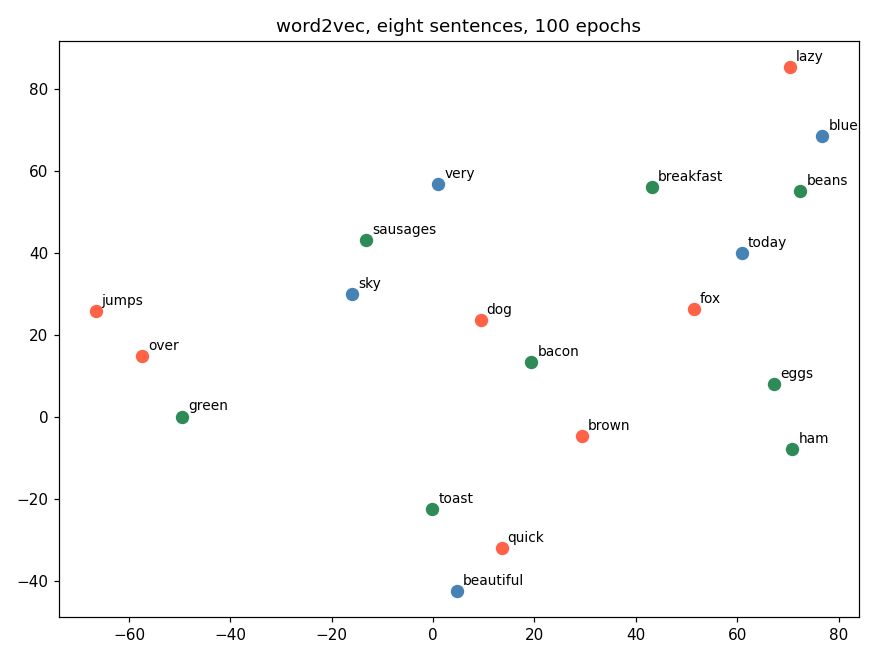

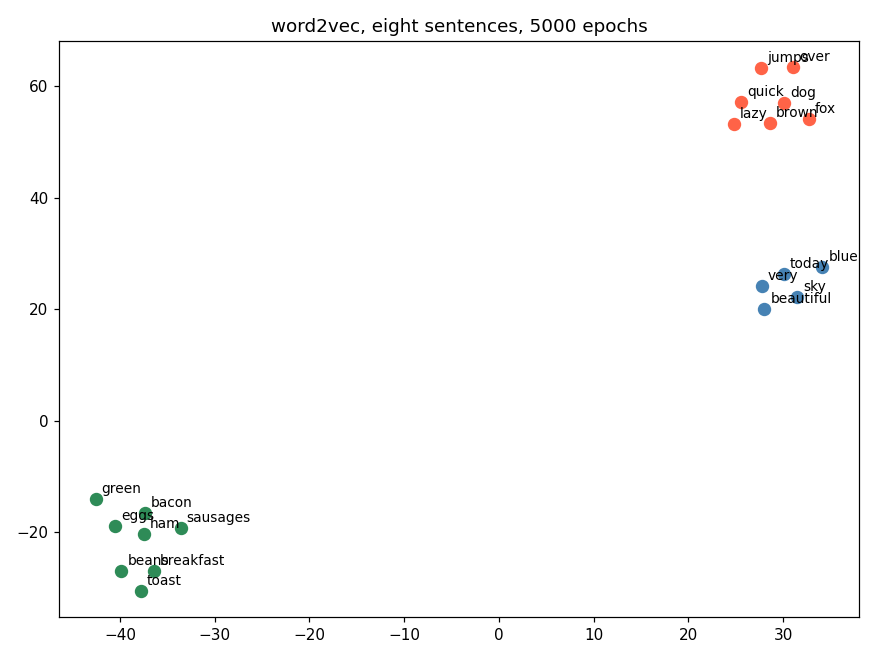

The first plot has the colours scattered. `blue` sits next to `beans`, `sky` next to `sausages`. The
second has three separated groups with nothing in between them.

This is the clearest picture in the lab of what training does, and it is worth remembering when a
model's output looks like noise. Undertrained and incapable look identical from the outside.

## 5.2 · What this model does not know

The `toy` model separates three topics cleanly, and it still knows nothing about English.

It has thirty words. Ask it about `cat`, `queen` or `Tuesday` and it raises an error, because those
words are not in the vocabulary and word2vec has no way to guess. The three groups it found are the
three groups that were written into eight sentences on purpose.

What it demonstrates is that the mechanism works, and that it works on data small enough to read every
word of. What it cannot demonstrate is anything about language, because it has not seen any. That
takes Part 3.

## Check yourself

- What is the only information word2vec ever sees during training?
- Which of CBOW and skip-gram produces more training examples from the same window, and why?
- What does `negative=5` do, and what would training cost without it?
- At 100 epochs `sky` was closer to `dog` than `fox` was. What changed at 5000?
- The toy model separates three topics. Why is that not evidence it understands the topics?
- Cosine similarity ignores vector length. Why is that the right choice for word vectors?

## Summary

word2vec learns one vector per word from co occurrence alone, with no definitions and no labels.
CBOW predicts the centre word from its context and skip-gram predicts the context from the centre
word, and gensim trains skip-gram with negative sampling so that the cost does not scale with the
vocabulary. The network is thrown away after training and the embedding matrix is the model. Eight
sentences are enough to see the mechanism work, given enough passes, and not enough to learn anything
about English.

**Next.** Part 3 trains the same algorithm on two million tokens, tries the analogy, and then shows
the three things static embeddings cannot do.

## Source

This Guided Lab was developed using and adapting material from
[ENC2045 Computational Linguistics](https://alvinntnu.github.io/NTNU_ENC2045/).

## References

**What this notebook used**

- [gensim `Word2Vec`](https://radimrehurek.com/gensim/models/word2vec.html). Every argument in the
  training cell: `vector_size`, `window`, `min_count`, `sg`, `negative`, `epochs`, `seed`, `workers`.
- [`KeyedVectors`](https://radimrehurek.com/gensim/models/keyedvectors.html). What `model.wv` is, and
  `similarity`, `most_similar` and `index_to_key`.
- [scikit-learn t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).
  What `perplexity` does and why the axes carry no meaning.

**Reading**

- Alammar and Grootendorst, *Hands-On Large Language Models*, chapter 2, the embeddings half.
  [UT Libraries](https://utk.primo.exlibrisgroup.com/permalink/01UTN_KNOXVILLE/bcmt7h/alma9926674015102311).
- [Jay Alammar, The Illustrated Word2vec](https://jalammar.github.io/illustrated-word2vec/). The
  visual version of sections 1 to 4.
- [Jurafsky and Martin, chapter 5, Embeddings](https://web.stanford.edu/~jurafsky/slp3/5.pdf), the
  sections on the distributional hypothesis, cosine similarity and skip-gram with negative sampling.